# 09 — Capstone: Connect the Ideas

## One constrained double integrator, from LQR terminal ingredients to Learning MPC

Notebooks 01–08 built the tools one at a time: the CFTOC as a quadratic program (notebook 01),
invariant and controllable sets (02), terminal ingredients and stability (03), Learning MPC (05)
and the dynamic-programming view that connects them (08). This capstone applies them together to
the constrained double integrator of notebooks 02 and 08 and checks every guarantee numerically.

Part A is one complete design: LQR terminal ingredients, a closed-loop check of recursive
feasibility and stability from a grid of initial states, the same controller without terminal
ingredients, and Learning MPC started from a deliberately poor trajectory. Part B turns the key
derivations into exercises with worked answers, Part C collects questions of engineering judgment,
and Part D points to further topics.

Throughout, keep apart a **guarantee**, which is proved for every state of a stated set, and an
**observation**, which holds for the cases that were simulated. The checks of Part A are built to
tell the two apart, including when the numerical solver, not the controller, is the weak link.

## Learning objectives

After working through this notebook, you should be able to:

1. build LQR terminal ingredients (DARE and maximal positively invariant admissible set) and check
   the terminal assumptions numerically;
2. compute the feasible sets of MPC as controllable sets and explain why they are control invariant;
3. verify recursive feasibility and the three Lyapunov conditions on a grid of states, and tell a
   solver failure apart from an infeasible problem;
4. explain what is lost without terminal ingredients, including feasible but doomed states;
5. say which features of a Learning MPC learning curve are guaranteed and which are not;
6. derive the condensed QP, its KKT conditions, the shifted-sequence and Lyapunov arguments, and the
   properties of the convex safe set and the barycentric terminal cost;
7. reason about model mismatch, disturbances, computation time, soft constraints, estimation, delays
   and fallbacks.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog, nnls

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.linear import dlqr, prediction_matrices
from advanced_mpc_lmpc.polytopes import (
    HPolytope,
    closed_loop_admissible_set_scalar_input,
    maximal_control_invariant,
    maximal_invariant,
    n_step_controllable_sets,
)
from advanced_mpc_lmpc.mpc import LinearMPC
from advanced_mpc_lmpc.lmpc import LMPCController, convex_safe_value, trajectory_cost_to_go
from advanced_mpc_lmpc.plotting import plot_polytope

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
})

## Table of Contents

- **[Part A — One design, end to end](#part-a)** — A.1 Model, constraints and LQR terminal ingredients · A.2 Feasible sets of MPC with terminal ingredients · A.3 Recursive feasibility and stability on a grid · A.4 Removing the terminal ingredients · A.5 Learning MPC from a poor first trajectory
- **[Part B — Derivations to reproduce](#part-b)** — B.1 The condensed QP · B.2 KKT conditions of the CFTOC · B.3 Recursive feasibility by the shifted sequence · B.4 Lyapunov decrease and the upper bound · B.5 Invariance of the convex safe set · B.6 The barycentric terminal cost
- **[Part C — Engineering judgment](#part-c)** — C.1 Model mismatch · C.2 Disturbances, robust and tube MPC · C.3 Real-time solvers · C.4 Soft constraints and slack penalties · C.5 Estimation and delays · C.6 Safety fallbacks
- **[Part D — Where to go next](#part-d)** — D.1 Robust and stochastic MPC · D.2 Nonlinear and economic MPC · D.3 Learning MPC beyond linear systems · D.4 Data-driven models · D.5 Embedded solvers · D.6 Projects on this repository
- **[Part E — Summary and references](#part-e)**

<a id="part-a"></a>
# Part A — One design, end to end

## A.1 Model, constraints and LQR terminal ingredients

The state $x=(p,v)$ is position and velocity, sampled with period $1$ under a piecewise-constant
acceleration $u$:

$$
x_{k+1}=Ax_k+Bu_k,
\qquad
A=\begin{bmatrix}1&1\\0&1\end{bmatrix},
\qquad
B=\begin{bmatrix}0.5\\1\end{bmatrix}.
$$

Constraints and stage cost are those of notebooks 02 and 08:

$$
\mathcal X=\{x:\ |p|\le4,\ |v|\le3\},
\qquad
\mathcal U=\{u:\ |u|\le1\},
\qquad
q(x,u)=x^\top Qx+u^\top Ru,
\quad
Q=\operatorname{diag}(1,0.2),\ R=0.2 .
$$

The MPC problem at the current state $x$ is

$$
J_N^\star(x)=\min_{u_0,\ldots,u_{N-1}}\ \sum_{k=0}^{N-1}q(x_k,u_k)+V_f(x_N)
\quad\text{s.t.}\quad
\begin{aligned}
&x_0=x,\quad x_{k+1}=Ax_k+Bu_k,\\
&x_k\in\mathcal X\ (k=1,\ldots,N),\quad u_k\in\mathcal U,\quad x_N\in\mathcal X_f,
\end{aligned}
$$

and $\mathcal X_N$ is the set of states of $\mathcal X$ where it is feasible. With a local controller
$u=-Kx$, notebook 03 (Part VI, where the terminal cost is called $p$) requires:

1. $\mathcal X_f\subseteq\mathcal X$ and $-Kx\in\mathcal U$ for all $x\in\mathcal X_f$;
2. $(A-BK)x\in\mathcal X_f$ for all $x\in\mathcal X_f$;
3. $V_f\big((A-BK)x\big)-V_f(x)\le-q(x,-Kx)$ for all $x\in\mathcal X_f$.

The LQR provides all three. With $P$ the stabilizing solution of the DARE

$$
P=Q+A^\top PA-A^\top PB\,(R+B^\top PB)^{-1}B^\top PA,
\qquad
K=(R+B^\top PB)^{-1}B^\top PA,
$$

the terminal cost $V_f(x)=x^\top Px$ satisfies condition 3 with **equality** for every $x$, because
the DARE is equivalent to $A_K^\top PA_K-P=-(Q+K^\top RK)$ with $A_K=A-BK$. For conditions 1 and
2, take $\mathcal X_f=\mathcal O_\infty$, the maximal positively invariant set of $x^+=A_Kx$ inside
$\mathcal X_K=\{x\in\mathcal X:\ -Kx\in\mathcal U\}$, computed with the recursion of notebook 02,

$$
\mathcal O_0=\mathcal X_K,
\qquad
\mathcal O_{i+1}=\mathcal X_K\cap\{x:\ A_Kx\in\mathcal O_i\},
$$

until $\mathcal O_{i+1}=\mathcal O_i$. The cell also computes the maximal control-invariant set
$\mathcal C_\infty$: the states from which *some* admissible input sequence keeps the state in
$\mathcal X$ forever.

K = [0.7396 1.2604]
P =
 [[1.7042 0.5   ]
 [0.5    0.7021]]
|eig(A - BK)| = [0.3308 0.3308]    ||DARE residual|| = 7.1e-16
terminal-set iterations: 2    vertices of X_f: 4
areas:  X = 48.00,  X_K = 12.66,  X_f = 7.31,  C_inf = 39.25

      p       v  u=-Kx  x in X  u in U  A_K x in X_f  decrease residual
-2.4042  2.2042   -1.0    True    True          True         1.7764e-15
-2.2042  0.5000    1.0    True    True          True         1.7764e-15
 2.4042 -2.2042    1.0    True    True          True         1.7764e-15
 2.2042 -0.5000   -1.0    True    True          True         1.7764e-15


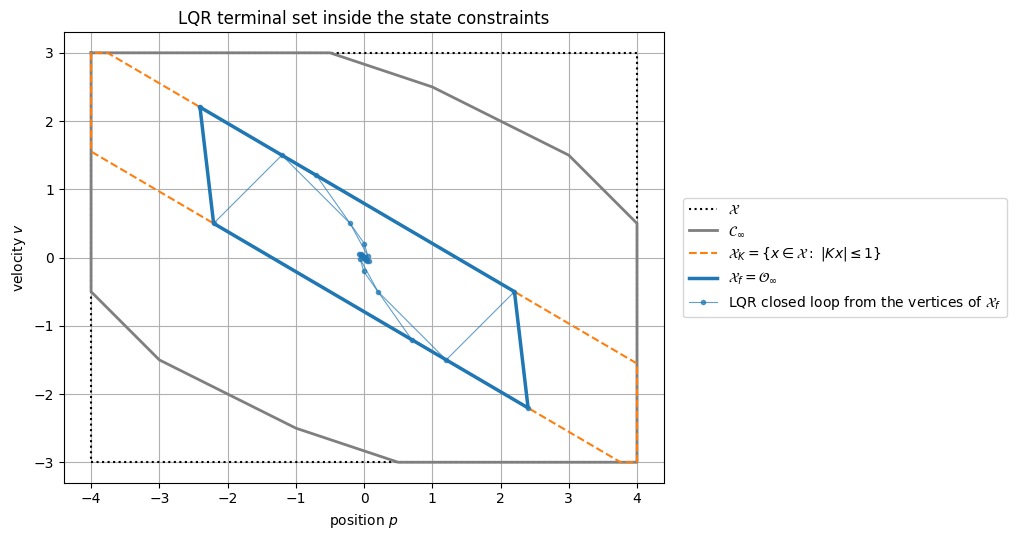

In [2]:
A = np.array([[1.0, 1.0],
              [0.0, 1.0]])
B = np.array([[0.5],
              [1.0]])
x_lower, x_upper = np.array([-4.0, -3.0]), np.array([4.0, 3.0])
umin, umax = -1.0, 1.0
X = HPolytope.box(x_lower, x_upper)

Q = np.diag([1.0, 0.2])
R = np.array([[0.2]])


def q(x, u):
    # Stage cost x'Qx + u'Ru.
    u = np.atleast_1d(u)
    return float(x @ Q @ x + u @ R @ u)


def area(S):
    # Area of a 2-D polytope (shoelace formula on its ordered vertices).
    V = S.vertices_2d()
    return 0.5 * abs(V[:, 0] @ np.roll(V[:, 1], -1) - V[:, 1] @ np.roll(V[:, 0], -1))


# LQR terminal controller u = -Kx and terminal cost V_f(x) = x'Px.
K, P, eig_cl = dlqr(A, B, Q, R)
A_K = A - B @ K
dare_residual = (Q + A.T @ P @ A
                 - A.T @ P @ B @ np.linalg.solve(R + B.T @ P @ B, B.T @ P @ A) - P)

# Terminal set: maximal positively invariant set of x+ = A_K x inside X_K = {x in X : -Kx in U}.
X_K = closed_loop_admissible_set_scalar_input(X, K, umin, umax)
X_f, X_f_history = maximal_invariant(A_K, X_K)
C_inf, _ = maximal_control_invariant(A, B, X, umin, umax)

print("K =", K.ravel())
print("P =\n", P)
print("|eig(A - BK)| =", np.abs(eig_cl), f"   ||DARE residual|| = {np.linalg.norm(dare_residual):.1e}")
print("terminal-set iterations:", len(X_f_history) - 1, "   vertices of X_f:", len(X_f.vertices_2d()))
print(f"areas:  X = {area(X):.2f},  X_K = {area(X_K):.2f},  X_f = {area(X_f):.2f},  C_inf = {area(C_inf):.2f}")

# The terminal conditions at the vertices of X_f. Conditions 1-2 at the vertices imply them on all
# of X_f (convex set, linear maps); condition 3 is an identity in x.
rows = []
for v in X_f.vertices_2d():
    u = -K @ v
    rows.append({
        "p": v[0], "v": v[1], "u=-Kx": u[0],
        "x in X": X.contains(v),
        "u in U": bool(umin - 1e-9 <= u[0] <= umax + 1e-9),
        "A_K x in X_f": X_f.contains(A_K @ v, tol=1e-9),
        "decrease residual": (A_K @ v) @ P @ (A_K @ v) - v @ P @ v + q(v, u),
    })
print()
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_polytope(ax, X, color="k", linestyle=":", label=r"$\mathcal{X}$")
plot_polytope(ax, C_inf, color="tab:gray", linewidth=2, label=r"$\mathcal{C}_\infty$")
plot_polytope(ax, X_K, color="tab:orange", linestyle="--", label=r"$\mathcal{X}_K=\{x\in\mathcal{X}:\ |Kx|\leq 1\}$")
plot_polytope(ax, X_f, color="tab:blue", linewidth=2.5, label=r"$\mathcal{X}_f=\mathcal{O}_\infty$")
for i, v in enumerate(X_f.vertices_2d()):
    traj = [v]
    for _ in range(6):
        traj.append(A_K @ traj[-1])
    traj = np.array(traj)
    ax.plot(traj[:, 0], traj[:, 1], "o-", color="tab:blue", markersize=3, linewidth=0.8, alpha=0.7,
            label="LQR closed loop from the vertices of $\\mathcal{X}_f$" if i == 0 else None)
ax.set_xlabel("position $p$")
ax.set_ylabel("velocity $v$")
ax.set_title("LQR terminal set inside the state constraints")
ax.set_aspect("equal")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

**Reading the output.** The recursion stops after two iterations with a four-vertex parallelogram.
Its long edges lie on the lines $|Kx|=1$ and the LQR input is $\pm1$ at every vertex: the input
bound, not the state box, limits $\mathcal X_f$. The decrease residual is at machine precision, as
the DARE identity predicts. $\mathcal X_f$ covers $7.31$ of the $48$ units of area of $\mathcal X$
and $\mathcal C_\infty$ covers $39.25$, so the finite horizon has to steer into $\mathcal X_f$ from a
much larger region.

## A.2 Feasible sets of MPC with terminal ingredients

The feasible set of the MPC problem is the $N$-step controllable set to $\mathcal X_f$ (notebook 02):

$$
\mathcal K_0=\mathcal X_f,
\qquad
\mathcal K_{i+1}=\mathcal X\cap\operatorname{Pre}(\mathcal K_i),
\qquad
\operatorname{Pre}(\mathcal S)=\{x:\ \exists u\in\mathcal U,\ Ax+Bu\in\mathcal S\},
\qquad
\mathcal X_N=\mathcal K_N .
$$

Because $\mathcal X_f$ is control invariant, $\mathcal X_f\subseteq\operatorname{Pre}(\mathcal X_f)$,
and induction gives a nested sequence

$$
\mathcal X_f=\mathcal K_0\subseteq\mathcal K_1\subseteq\mathcal K_2\subseteq\cdots\subseteq\mathcal C_\infty .
$$

Each $\mathcal K_i$ is control invariant as well: from $x\in\mathcal K_i$ some admissible input
reaches $\mathcal K_{i-1}\subseteq\mathcal K_i$. This set-level statement **is** recursive
feasibility; Exercise B.3 proves it for input sequences.

 N  area of X_N  fraction of C_inf  X_(N-1) inside X_N  X_N = C_inf
 0       7.3125             0.1863                True        False
 1      19.3479             0.4929                True        False
 2      27.6199             0.7037                True        False
 3      34.3364             0.8748                True        False
 4      38.0748             0.9701                True        False
 5      39.2500             1.0000                True         True
 6      39.2500             1.0000                True         True


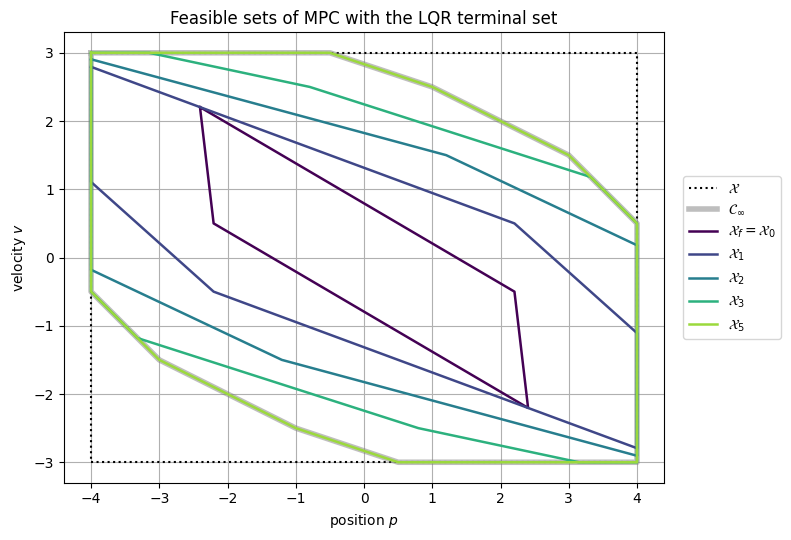

In [3]:
N_max = 6
feasible_sets = n_step_controllable_sets(A, B, X, X_f, umin, umax, N_max)   # feasible_sets[N] = X_N

rows = []
for N, S in enumerate(feasible_sets):
    rows.append({
        "N": N,
        "area of X_N": area(S),
        "fraction of C_inf": area(S) / area(C_inf),
        "X_(N-1) inside X_N": N == 0 or all(S.contains(v, 1e-9) for v in feasible_sets[N - 1].vertices_2d()),
        "X_N = C_inf": S.approximately_equal(C_inf, 1e-7),
    })
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_polytope(ax, X, color="k", linestyle=":", label=r"$\mathcal{X}$")
plot_polytope(ax, C_inf, color="tab:gray", linewidth=4, alpha=0.5, label=r"$\mathcal{C}_\infty$")
colors = plt.cm.viridis(np.linspace(0.0, 0.85, 5))
for color, N in zip(colors, [0, 1, 2, 3, 5]):
    label = r"$\mathcal{X}_f=\mathcal{X}_0$" if N == 0 else rf"$\mathcal{{X}}_{{{N}}}$"
    plot_polytope(ax, feasible_sets[N], color=color, linewidth=1.8, label=label)
ax.set_xlabel("position $p$")
ax.set_ylabel("velocity $v$")
ax.set_title("Feasible sets of MPC with the LQR terminal set")
ax.set_aspect("equal")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

**Reading the output.** The sets are nested and grow quickly: about half of $\mathcal C_\infty$ for
$N=1$, $87\%$ for $N=3$, and all of it from $N=5$. From that horizon on, the terminal constraint
costs no region of attraction. Below it, states of $\mathcal C_\infty\setminus\mathcal X_N$ are
rejected, although some controller could keep them in $\mathcal X$.

## A.3 Recursive feasibility and stability on a grid

**What the theory promises** (notebook 03, Parts IV.3 and VI; Exercises B.3 and B.4). For every
initial state in $\mathcal X_N$:

1. the MPC problem remains feasible at every step;
2. the value decreases, $J_N^\star(x^+)-J_N^\star(x)\le-q\big(x,\kappa_N(x)\big)$, where
   $\kappa_N(x)=u_0^\star(x)$ is the MPC law;
3. $J_N^\star(x)\ge\lambda_{\min}(Q)\|x\|^2$ everywhere and
   $J_N^\star(x)\le V_f(x)\le\lambda_{\max}(P)\|x\|^2$ on $\mathcal X_f$.

These are the three Lyapunov conditions of notebook 03, so the origin is exponentially stable with
region of attraction $\mathcal X_N$. The LQR ingredients add one fact: from $x\in\mathcal X_f$ the
LQR plan is admissible and optimal, because $P$ is a fixed point of the Riccati recursion. Hence
$J_N^\star=V_f$ and $\kappa_N(x)=-Kx$ on $\mathcal X_f$: inside the terminal set, the MPC **is** the
LQR.

**What we check.** Each point of a grid with spacing $0.5$ over $\mathcal X$ ($17\times13=221$
states) that is feasible for $N\in\{2,3,5\}$ starts a 40-step closed loop. We record feasibility,
the decrease residual $J_N^\star(x^+)-J_N^\star(x)+q(x,u)$ (theory: $\le0$) and the entry into
$\mathcal X_f$.

**An auditable solver.** `LinearMPC` uses SciPy's SLSQP, which can report failure on degenerate but
feasible QPs (at boundary states of $\mathcal X_N$, where the feasible input sequences have an empty
interior) and, with its absolute objective tolerance, can stop early near the origin. A failure flag
is not an infeasibility certificate. `solve_mpc` therefore calls `LinearMPC.solve` first and, on
failure, solves an LP for the smallest $s\ge0$ such that some input sequence satisfies all
constraints relaxed by $s$: $s=0$ certifies feasibility, $s>0$ infeasibility. A feasible QP is then
solved exactly: with $H=LL^\top$ and $z=L^\top U+L^{-1}f$ it becomes a least-distance problem, which
one non-negative least-squares problem solves (Lawson and Hanson, 1974), with the constraints relaxed
by $10^{-8}$ against round-off. Every fallback is logged; the QP data follow Exercise B.1.

In [4]:
FEAS_TOL = 1e-6   # an LP violation above this certifies infeasibility
RELAX = 1e-8      # constraint relaxation in the exact fallback (round-off on the boundary)


def make_mpc(N, terminal=True):
    # MPC with the LQR terminal ingredients, or the plain variant: V_f = 0 and no terminal set.
    common = dict(x_lower=x_lower, x_upper=x_upper, u_lower=[umin], u_upper=[umax])
    if terminal:
        return LinearMPC(A, B, Q, R, N=N, P=P, terminal_H=X_f.H, terminal_h=X_f.h, **common)
    return LinearMPC(A, B, Q, R, N=N, P=np.zeros((2, 2)), **common)


def qp_data(ctrl, x0):
    # Condensed QP of LinearMPC: cost 1/2 U'HU + f'U + c, constraints G U <= w (Exercise B.1).
    N, n, m = ctrl.N, ctrl.n, ctrl.m
    Qbar = np.kron(np.eye(N), ctrl.Q)
    Qbar[-n:, -n:] = ctrl.P
    Rbar = np.kron(np.eye(N), ctrl.R)
    free = ctrl.Sx @ x0                                    # predicted states for U = 0
    H = 2 * (ctrl.Su.T @ Qbar @ ctrl.Su + Rbar)
    f = 2 * ctrl.Su.T @ Qbar @ free
    c = x0 @ ctrl.Q @ x0 + free @ Qbar @ free
    G = [ctrl.Su, -ctrl.Su, np.eye(N * m), -np.eye(N * m)]
    w = [np.tile(ctrl.x_upper, N) - free, free - np.tile(ctrl.x_lower, N),
         np.tile(ctrl.u_upper, N), -np.tile(ctrl.u_lower, N)]
    if ctrl.terminal_H is not None:
        G.append(ctrl.terminal_H @ ctrl.Su[-n:])
        w.append(ctrl.terminal_h - ctrl.terminal_H @ free[-n:])
    return H, f, c, np.vstack(G), np.concatenate(w)


def min_violation(G, w):
    # LP: smallest s >= 0 such that G U <= w + s has a solution (s = 0 <=> the QP is feasible).
    nU = G.shape[1]
    res = linprog(np.r_[np.zeros(nU), 1.0], A_ub=np.hstack([G, -np.ones((len(w), 1))]), b_ub=w,
                  bounds=[(None, None)] * nU + [(0.0, None)], method="highs")
    return float(res.fun)


def exact_qp(H, f, G, w):
    # min 1/2 U'HU + f'U  s.t.  G U <= w  (H > 0), as a least-distance problem solved by NNLS.
    L_inv = np.linalg.inv(np.linalg.cholesky(H))
    E = G @ L_inv.T                       # with z = L'U + L^{-1} f:  min ||z||  s.t.  E z <= d
    d = w + E @ (L_inv @ f)
    M = -np.vstack([E.T, d])
    e = np.r_[np.zeros(E.shape[1]), 1.0]
    y, _ = nnls(M, e, maxiter=100 * len(d))
    r = M @ y - e
    z = -r[:-1] / r[-1]
    return L_inv.T @ (z - L_inv @ f)


solver_log = {"slsqp": 0, "fallback": 0, "infeasible": 0}
fallback_cases = []                       # (state, LP violation, constraint violation of the answer)
infeasible_margins = []                   # LP violation s of every QP certified infeasible


def solve_mpc(ctrl, x, warm=None):
    # Returns (U, status), status in {"slsqp", "fallback", "infeasible"}.
    sol = ctrl.solve(x, warm=warm)
    if sol.success:
        status, U = "slsqp", sol.U.ravel()
    else:
        H, f, c, G, w = qp_data(ctrl, x)
        s = min_violation(G, w)
        if s > FEAS_TOL:
            status, U = "infeasible", None
            infeasible_margins.append(s)
        else:
            status, U = "fallback", exact_qp(H, f, G, w + max(RELAX, 2 * s))
            fallback_cases.append((x.copy(), s, float(np.max(G @ U - w))))
    solver_log[status] += 1
    return U, status


def plan_cost(ctrl, x, U):
    # Full cost of the plan U from x: sum of q(x_k, u_k) for k < N plus x_N' P x_N.
    H, f, c, _, _ = qp_data(ctrl, x)
    return float(0.5 * U @ H @ U + f @ U + c)


def closed_loop(ctrl, x0, steps=40):
    # Receding-horizon simulation; warm start = shifted plan completed by the (clipped) LQR step.
    x = np.asarray(x0, float)
    xs, us, J, status = [x], [], [], []
    warm = None
    for _ in range(steps):
        U, st = solve_mpc(ctrl, x, warm)
        status.append(st)
        if U is None:
            break
        J.append(plan_cost(ctrl, x, U))
        x_N = ctrl.Sx[-ctrl.n:] @ x + ctrl.Su[-ctrl.n:] @ U
        warm = np.r_[U[1:], np.clip(-K @ x_N, umin, umax)]
        x = A @ x + B @ U[:1]
        xs.append(x)
        us.append(U[0])
    return {"x": np.array(xs), "u": np.array(us), "J": np.array(J), "status": status,
            "lost": status[-1] == "infeasible"}

In [5]:
grid = np.array([[p, v] for v in np.arange(-3.0, 3.01, 0.5) for p in np.arange(-4.0, 4.01, 0.5)])


def is_feasible(ctrl, x0):
    H, f, c, G, w = qp_data(ctrl, x0)
    return min_violation(G, w) <= FEAS_TOL


runs_terminal, rows = {}, []
for N in [2, 3, 5]:
    ctrl = make_mpc(N)
    log_before = dict(solver_log)
    runs = []
    for x0 in grid:
        if not is_feasible(ctrl, x0):
            continue
        n_cases = len(fallback_cases)
        run = closed_loop(ctrl, x0)
        for x, s, viol in fallback_cases[n_cases:]:
            print(f"N = {N}, start {x0}: fallback at x = {np.round(x, 6)}, LP violation s = {s:.1e}, "
                  f"constraint violation of the exact solution = {viol:.1e}")
        stage = np.array([q(x, u) for x, u in zip(run["x"][:-1], run["u"])])
        run["residual"] = run["J"][1:] - run["J"][:-1] + stage[:-1]
        run["enter_Xf"] = next((t for t, x in enumerate(run["x"]) if X_f.contains(x, 1e-9)), np.inf)
        runs.append(run)
    runs_terminal[N] = runs
    solves = {k: solver_log[k] - log_before[k] for k in solver_log}
    rows.append({
        "N": N,
        "feasible starts": len(runs),
        "lost feasibility": sum(r["lost"] for r in runs),
        "max decrease residual": max(r["residual"].max() for r in runs),
        "max steps to X_f": max(r["enter_Xf"] for r in runs),
        "max |x_40|": max(np.linalg.norm(r["x"][-1]) for r in runs),
        "QPs solved": sum(solves.values()),
        "SLSQP fallbacks": solves["fallback"],
    })
print(f"grid states: {len(grid)}")
print(pd.DataFrame(rows).to_string(index=False))

# Upper bound on X_f: random states of X_f, compare J_N^*(x) with V_f(x) and the MPC input with -Kx.
rng = np.random.default_rng(0)
V_Xf = X_f.vertices_2d()
samples = [x for x in rng.uniform(V_Xf.min(axis=0), V_Xf.max(axis=0), size=(1000, 2)) if X_f.contains(x)][:200]
ctrl3 = make_mpc(3)
value_gap, input_gap = [], []
for x in samples:
    U, _ = solve_mpc(ctrl3, x)
    value_gap.append(abs(plan_cost(ctrl3, x, U) - x @ P @ x))
    input_gap.append(abs(U[0] + (K @ x)[0]))
print(f"\n{len(samples)} random states of X_f, N = 3:  max |J_N^* - V_f| = {max(value_gap):.1e},"
      f"  max |u_0^* + Kx| = {max(input_gap):.1e}")
print(f"lambda_min(Q) = {np.linalg.eigvalsh(Q).min():.3f},  lambda_max(P) = {np.linalg.eigvalsh(P).max():.3f}")

N = 5, start [1.  2.5]: fallback at x = [4.  0.5], LP violation s = 0.0e+00, constraint violation of the exact solution = 1.0e-08
grid states: 221
 N  feasible starts  lost feasibility  max decrease residual  max steps to X_f  max |x_40|  QPs solved  SLSQP fallbacks
 2              117                 0             1.0658e-14                 3  1.3901e-18        4680                0
 3              147                 0             2.8422e-14                 4  8.6524e-18        5880                0
 5              177                 0             5.2633e-08                 6  4.4611e-17        7080                1



200 random states of X_f, N = 3:  max |J_N^* - V_f| = 4.4e-09,  max |u_0^* + Kx| = 4.4e-05
lambda_min(Q) = 0.200,  lambda_max(P) = 1.911


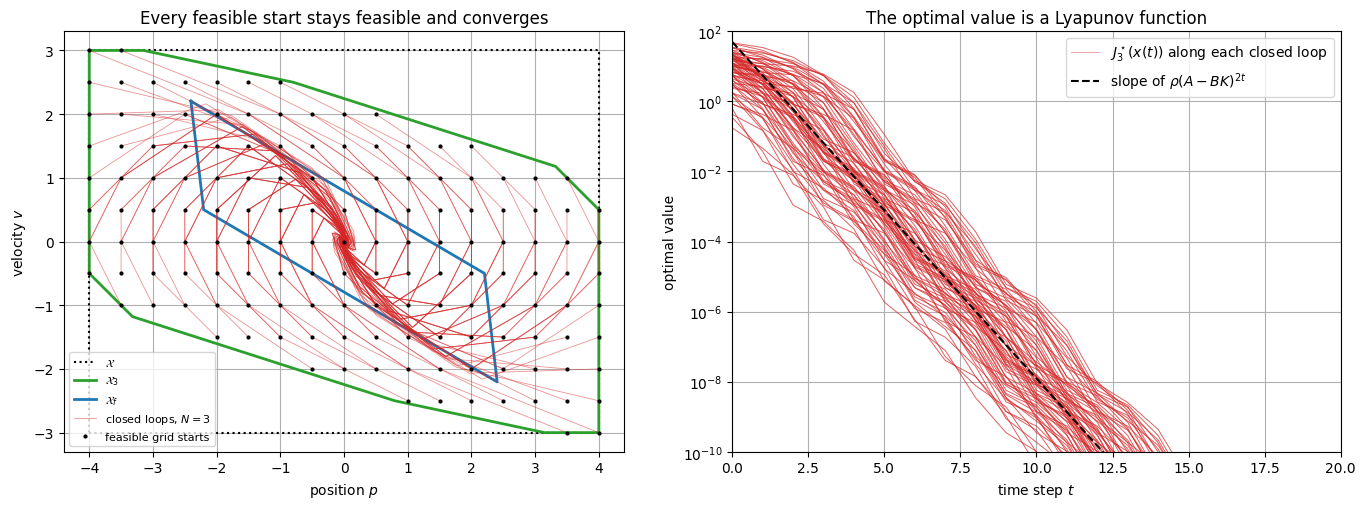

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
plot_polytope(ax, X, color="k", linestyle=":", label=r"$\mathcal{X}$")
plot_polytope(ax, feasible_sets[3], color="tab:green", linewidth=2, label=r"$\mathcal{X}_3$")
plot_polytope(ax, X_f, color="tab:blue", linewidth=2, label=r"$\mathcal{X}_f$")
for i, r in enumerate(runs_terminal[3]):
    ax.plot(r["x"][:, 0], r["x"][:, 1], color="tab:red", linewidth=0.6, alpha=0.5,
            label="closed loops, $N=3$" if i == 0 else None)
starts = np.array([r["x"][0] for r in runs_terminal[3]])
ax.plot(starts[:, 0], starts[:, 1], "k.", markersize=4, label="feasible grid starts")
ax.set_xlabel("position $p$")
ax.set_ylabel("velocity $v$")
ax.set_title("Every feasible start stays feasible and converges")
ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=8)

ax = axes[1]
for i, r in enumerate(runs_terminal[3]):
    if r["J"][0] > 0:
        ax.semilogy(r["J"], color="tab:red", linewidth=0.6, alpha=0.5,
                    label=r"$J_3^\star(x(t))$ along each closed loop" if i == 0 else None)
rho = np.max(np.abs(eig_cl))
t = np.arange(0, 21)
ax.semilogy(t, 50 * rho ** (2 * t), "k--", label=r"slope of $\rho(A-BK)^{2t}$")
ax.set_xlim(0, 20)
ax.set_ylim(1e-10, 1e2)
ax.set_xlabel("time step $t$")
ax.set_ylabel("optimal value")
ax.set_title("The optimal value is a Lyapunov function")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Reading the output.** For $N=2$, $3$ and $5$ the grid has $117$, $147$ and $177$ feasible starts
(for $N=5$, every grid state of $\mathcal C_\infty$). Every closed loop stayed feasible and entered
$\mathcal X_f$ within $3$, $4$ and $6$ steps, after which the value decays with the slope of
$\rho(A-BK)^{2t}$, $\rho(A-BK)=0.331$ (right panel). The largest decrease residual over all
$17\,640$ closed-loop QPs is $5.3\times10^{-8}$, zero up to solver tolerance. On $200$ random states of
$\mathcal X_f$, $J_3^\star$ matches $V_f$ to $4\times10^{-9}$ and the first input matches $-Kx$ to
$4\times10^{-5}$ (the tolerance acts on the objective, which is quadratic in the input error): the
upper bound holds with equality.

One QP needed the fallback, at $x=(4,0.5)$, a vertex of $\mathcal C_\infty$ reached from $(1,2.5)$
with $N=5$. The position is at its bound with the velocity pointing outward, so
$p_1=4.5+0.5u_0\le4$ forces $u_0=-1$; the feasible input sequences lie in a hyperplane, and SLSQP
declared the constraints incompatible. The LP certified feasibility ($s=0$), and the exact solver
returned a plan within the $10^{-8}$ relaxation. This is a solver artefact, not a counterexample to
recursive feasibility.

## A.4 Removing the terminal ingredients

The textbook variant drops both ingredients, $V_f=0$ and no terminal set:

$$
J_N^{0}(x)=\min_{u_0,\ldots,u_{N-1}}\ \sum_{k=0}^{N-1}q(x_k,u_k)
\quad\text{s.t.}\quad
x_{k+1}=Ax_k+Bu_k,\ \ x_k\in\mathcal X\ (k=1,\ldots,N),\ \ u_k\in\mathcal U .
$$

Its feasible set is $\mathcal K_N(\mathcal X)$, the states that can be kept in $\mathcal X$ for $N$
steps (the recursion of A.2 started from $\mathcal K_0=\mathcal X$). This sequence *shrinks* towards
$\mathcal C_\infty$, and for short horizons it contains **doomed** states: the QP is feasible now,
yet every admissible input sequence leaves $\mathcal X$ eventually. None of the proofs of A.3
applies.

The cell runs the plain controller from the grid for $N=1,\ldots,5$. A run counts as converged if it
stays feasible and $\|x_{40}\|\le10^{-3}$ (without the LQR step in its warm start, SLSQP stalls near
$10^{-4}$, which says nothing about the controller). Costs are compared with $J_\infty^\star(x_0)$,
sandwiched between $J_{12}^\star$ of the terminal design, an upper bound because its plan followed
by the LQR is admissible, and $J_{30}^0$ of the plain problem, a lower bound because it drops the
tail.

In [7]:
# Reference: J_inf^*(x0) for every grid state of C_inf, sandwiched between two finite-horizon values.
ref_upper, ref_lower = make_mpc(12), make_mpc(30, terminal=False)
log_before = dict(solver_log)
J_inf, sandwich_gap = {}, 0.0
for x0 in grid:
    if C_inf.contains(x0, 1e-9):
        upper = plan_cost(ref_upper, x0, solve_mpc(ref_upper, x0)[0])
        lower = plan_cost(ref_lower, x0, solve_mpc(ref_lower, x0)[0])
        J_inf[tuple(x0)] = upper
        sandwich_gap = max(sandwich_gap, upper - lower)
print(f"J_inf^* on {len(J_inf)} grid states of C_inf: max(upper - lower) = {sandwich_gap:.1e}, "
      f"fallbacks needed: {solver_log['fallback'] - log_before['fallback']}")


def cost_ratio(run):
    # Closed-loop cost over the simulated steps divided by J_inf^*(x0).
    return sum(q(x, u) for x, u in zip(run["x"][:-1], run["u"])) / J_inf[tuple(run["x"][0])]


# K_0 = X, K_(N+1) = X n Pre(K_N): the states that can be kept in X for N more steps.
plain_sets = n_step_controllable_sets(A, B, X, X, umin, umax, 5)    # plain_sets[N] = K_N(X)
runs_plain, rows, mismatches = {}, [], 0
log_before = dict(solver_log)
for N in range(1, 6):
    ctrl = make_mpc(N, terminal=False)
    runs = []
    for x0 in grid:
        feasible = is_feasible(ctrl, x0)
        mismatches += feasible != plain_sets[N].contains(x0, 1e-9)
        if not feasible:
            continue
        run = closed_loop(ctrl, x0)
        run["doomed"] = not C_inf.contains(x0, 1e-9)
        run["converged"] = not run["lost"] and np.linalg.norm(run["x"][-1]) <= 1e-3
        if run["converged"] and np.linalg.norm(x0) > 0:
            run["ratio"] = cost_ratio(run)
        runs.append(run)
    runs_plain[N] = runs
    ratios = [r["ratio"] for r in runs if "ratio" in r]
    rows.append({
        "N": N,
        "area K_N(X)": area(plain_sets[N]),
        "doomed area": area(plain_sets[N]) - area(C_inf),
        "feasible starts": len(runs),
        "doomed starts": sum(r["doomed"] for r in runs),
        "lost, start in C_inf": sum(r["lost"] and not r["doomed"] for r in runs),
        "lost, doomed start": sum(r["lost"] and r["doomed"] for r in runs),
        "feasible, no convergence": sum(not r["lost"] and not r["converged"] for r in runs),
        "worst cost/J_inf": max(ratios) if ratios else np.nan,
        "starts > 1.2 J_inf": sum(r > 1.2 for r in ratios),
    })
print(pd.DataFrame(rows).to_string(index=False))
print(f"\ngrid states where membership in K_N(X) and the LP feasibility test disagree: {mismatches}")
print("doomed grid starts accepted by the plain MPC with N = 2:",
      [(float(r["x"][0][0]), float(r["x"][0][1])) for r in runs_plain[2] if r["doomed"]])
print(f"QPs certified infeasible: {solver_log['infeasible'] - log_before['infeasible']}, smallest LP violation "
      f"among them: {min(infeasible_margins):.2f};  SLSQP fallbacks: {solver_log['fallback'] - log_before['fallback']}")

for N in [2, 3, 5]:
    worst = max(cost_ratio(r) for r in runs_terminal[N] if np.linalg.norm(r["x"][0]) > 0)
    print(f"terminal design, N = {N}: worst cost/J_inf over its feasible grid starts = {worst:.4f}")

for N in [2, 3]:
    steps = violations = increases = 0
    for r in runs_plain[N]:
        if r["lost"]:
            continue
        stage = np.array([q(x, u) for x, u in zip(r["x"][:-1], r["u"])])
        away = np.linalg.norm(r["x"][:len(r["J"]) - 1], axis=1) > 1e-2   # ignore solver noise near 0
        dJ = r["J"][1:] - r["J"][:-1]
        steps += int(away.sum())
        violations += int(np.sum((dJ + stage[:len(dJ)] > 1e-9) & away))
        increases += int(np.sum((dJ > 1e-9) & away))
    print(f"plain design, N = {N}: at the {steps} steps with |x| > 0.01, the decrease inequality is "
          f"violated {violations} times and the value increases {increases} times")

J_inf^* on 177 grid states of C_inf: max(upper - lower) = 6.9e-09, fallbacks needed: 0


 N  area K_N(X)  doomed area  feasible starts  doomed starts  lost, start in C_inf  lost, doomed start  feasible, no convergence  worst cost/J_inf  starts > 1.2 J_inf
 1        41.75         2.50              191             14                   100                  14                        76               NaN                   0
 2        39.50         0.25              179              2                     0                   2                         0            2.1459                  24
 3        39.25         0.00              177              0                     0                   0                         0            1.0945                   0
 4        39.25         0.00              177              0                     0                   0                         0            1.0032                   0
 5        39.25         0.00              177              0                     0                   0                         0            1.0000                   

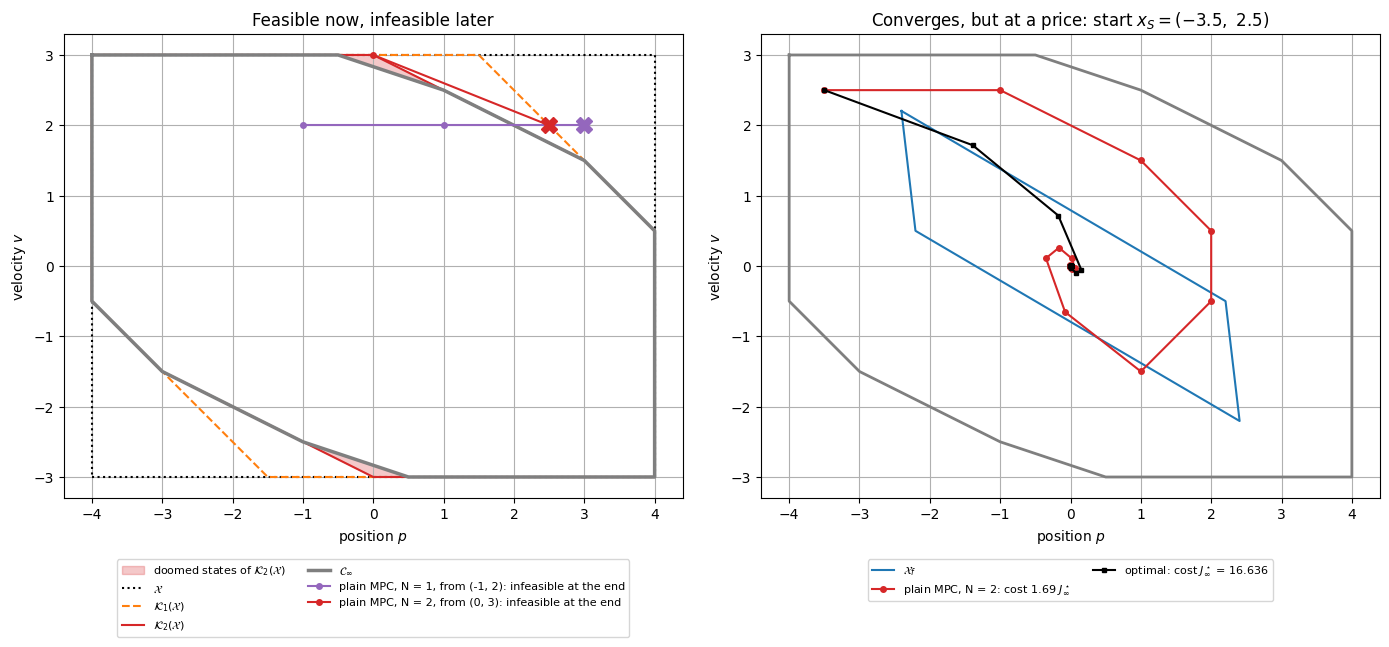

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.6))

ax = axes[0]
V2 = plain_sets[2].vertices_2d()
ax.fill(V2[:, 0], V2[:, 1], color="tab:red", alpha=0.25, label=r"doomed states of $\mathcal{K}_2(\mathcal{X})$")
Vc = C_inf.vertices_2d()
ax.fill(Vc[:, 0], Vc[:, 1], color="white")
plot_polytope(ax, X, color="k", linestyle=":", label=r"$\mathcal{X}$")
plot_polytope(ax, plain_sets[1], color="tab:orange", linestyle="--", label=r"$\mathcal{K}_1(\mathcal{X})$")
plot_polytope(ax, plain_sets[2], color="tab:red", label=r"$\mathcal{K}_2(\mathcal{X})$")
plot_polytope(ax, C_inf, color="tab:gray", linewidth=2.5, label=r"$\mathcal{C}_\infty$")
examples = [(1, np.array([-1.0, 2.0]), "tab:purple"), (2, np.array([0.0, 3.0]), "tab:red")]
for N, x0, color in examples:
    r = closed_loop(make_mpc(N, terminal=False), x0)
    ax.plot(r["x"][:, 0], r["x"][:, 1], "o-", color=color, markersize=4,
            label=f"plain MPC, N = {N}, from ({x0[0]:g}, {x0[1]:g})" + (": infeasible at the end" if r["lost"] else ""))
    ax.plot(*r["x"][-1], "X", color=color, markersize=12)
ax.set_xlabel("position $p$")
ax.set_ylabel("velocity $v$")
ax.set_title("Feasible now, infeasible later")
ax.set_aspect("equal")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8)

ax = axes[1]
x_S = np.array([-3.5, 2.5])
r_plain = closed_loop(make_mpc(2, terminal=False), x_S)
r_opt = closed_loop(make_mpc(12), x_S)
plot_polytope(ax, C_inf, color="tab:gray", linewidth=2)
plot_polytope(ax, X_f, color="tab:blue", linewidth=1.5, label=r"$\mathcal{X}_f$")
ax.plot(r_plain["x"][:, 0], r_plain["x"][:, 1], "o-", color="tab:red", markersize=4,
        label=f"plain MPC, N = 2: cost {cost_ratio(r_plain):.2f} $J_\\infty^\\star$")
ax.plot(r_opt["x"][:, 0], r_opt["x"][:, 1], "s-", color="k", markersize=3,
        label=f"optimal: cost $J_\\infty^\\star$ = {J_inf[tuple(x_S)]:.3f}")
ax.set_xlabel("position $p$")
ax.set_ylabel("velocity $v$")
ax.set_title(r"Converges, but at a price: start $x_S=(-3.5,\ 2.5)$")
ax.set_aspect("equal")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

**Reading the output.** The two bounds on $J_\infty^\star$ differ by at most $6.9\times10^{-9}$, the
sets $\mathcal K_N(\mathcal X)$ agree with the LP test at every grid state, and each of the 116
infeasible QPs violates its constraints by at least $0.17$, far from any tolerance.

- **$N=1$ fails badly.** $u_0=0$ minimizes $q(x_0,u_0)$ whenever $Ax\in\mathcal X$, so the
  controller coasts until a bound forces it to brake, then brakes as little as possible. States
  $(p,0)$ are equilibria and moving states coast from wall to wall, so 76 feasible starts never
  converge, and from 100 of the 177 starts in $\mathcal C_\infty$ it coasts into a state where one
  braking step is not enough: from $(-1,2)$ to $(3,2)$, where $p_1=5+0.5u\le4$ would need $u\le-2$.
  All 14 doomed starts fail too.
- **$N=2$ accepts doomed states.** Both doomed grid starts, $(0,\pm3)$, in the shaded slivers of
  area $0.25$, lose feasibility. Every start in $\mathcal C_\infty$ converges, but at up to
  $2.15\,J_\infty^\star$, and 24 starts pay more than $20\%$ extra. From $x_S=(-3.5,2.5)$ the
  controller keeps its speed too long, overshoots to $p=2$ and spirals back, at
  $1.69\,J_\infty^\star$. With the terminal ingredients and the same $N$, the worst ratio is $1.0010$.
- **From $N=3$ on, nothing visibly goes wrong.** $\mathcal K_3(\mathcal X)=\mathcal C_\infty$, and
  the worst costs are $1.0945$, $1.0032$ and $1.0000$ times $J_\infty^\star$ for $N=3,4,5$.

**What is lost is the certificate.** With $V_f=0$ the principle of optimality gives
$J_N^0(x)=q(x,u_0^\star)+J_{N-1}^0(x^+)$, hence

$$
J_N^0(x^+)-J_N^0(x)+q(x,u_0^\star)=J_N^0(x^+)-J_{N-1}^0(x^+)\ \ge\ 0,
$$

because with a zero terminal cost a longer horizon can only add cost (notebook 08, Part V). The
decrease inequality of A.3 holds **with the wrong sign**. It fails at all 2060 ($N=2$) and 1352
($N=3$) steps away from the origin, and the value even increases at 118 and 42 of them. Proofs for
MPC without terminal ingredients exist, but they need a long enough horizon and controllability
assumptions (Part D). The terminal ingredients give the guarantee at every horizon.

## A.5 Learning MPC from a poor first trajectory

Learning MPC (notebook 05) replaces the designed terminal ingredients by data. The task is repeated
from the same initial state $x_S$. The states of every trajectory that reached the target become
rows of a matrix $S$, and their realized costs-to-go form a vector $\mathbf J$. Iteration $j$ solves

$$
\min_{u_0,\ldots,u_{N-1},\,\lambda}\ \sum_{k=0}^{N-1}q(x_k,u_k)+\mathbf J^\top\lambda
\quad\text{s.t.}\quad
\begin{aligned}
&x_0=x,\quad x_{k+1}=Ax_k+Bu_k,\quad x_k\in\mathcal X,\quad u_k\in\mathcal U,\\
&x_N=S^\top\lambda,\quad \mathbf 1^\top\lambda=1,\quad \lambda\ge0 .
\end{aligned}
$$

The terminal set is the convex safe set $CS^j$, the convex hull of the stored states, and the
terminal cost is the barycentric value
$V_c^j(x_N)=\min\{\mathbf J^\top\lambda:\ S^\top\lambda=x_N,\ \mathbf 1^\top\lambda=1,\ \lambda\ge0\}$
(Exercises B.5 and B.6). For linear dynamics, convex constraints and a convex stage cost, notebook 05
shows that every iteration is recursively feasible and converges to the target; that
$J^{j+1}(x_S)\le J^j(x_S)$, because the previous trajectory remains a feasible candidate; and, since
each iteration is admissible, $J^j(x_S)\ge J_\infty^\star(x_S)$. The costs therefore converge, but
convergence **to** $J_\infty^\star$ is not among the guarantees.

**Setup.** $x_S=(-3.5,2.5)$, and the first trajectory is the plain $N=2$ closed loop of A.4,
feasible but at $1.69\,J_\infty^\star$. As in notebook 05, stored trajectories must end exactly at
the target, so each run stops once $\|x\|\le10^{-3}$ and is completed by the two inputs
$[u_0;\,u_1]=-[AB\ \ B]^{-1}A^2x$, which reach the origin exactly. LMPC then runs 10 iterations for
each $N\in\{2,3,4\}$ with all stored data.

In [9]:
def complete_to_origin(X_list, U_list):
    # Two-step deadbeat completion [AB B][u0; u1] = -A^2 x, which reaches x = 0 exactly.
    x = X_list[-1]
    for u in np.linalg.solve(np.column_stack([A @ B, B]), -A @ A @ x):
        assert umin <= u <= umax
        U_list.append(np.array([u]))
        X_list.append(A @ X_list[-1] + B[:, 0] * u)
        assert X.contains(X_list[-1])
    X_list[-1] = np.zeros(2)          # remove round-off: the stored trajectory ends at the target
    return np.array(X_list), np.array(U_list)


def lmpc_iteration(lmpc, x0, max_steps=60):
    # One execution of the task with LMPC; the successful trajectory is added to the data.
    x, X_list, U_list, warm = x0.copy(), [x0.copy()], [], None
    while np.linalg.norm(x) > 1e-3:
        sol = lmpc.solve(x, warm=warm)
        if not sol.success or len(U_list) == max_steps:
            raise RuntimeError(f"LMPC failed at x = {x}: {sol.message}")
        x = A @ x + B @ sol.U[0]
        X_list.append(x)
        U_list.append(sol.U[0].copy())
        warm = lmpc.shifted_warm_start(x, sol)
    X_traj, U_traj = complete_to_origin(X_list, U_list)
    lmpc.add_trajectory(X_traj, U_traj)
    return X_traj


x_S = np.array([-3.5, 2.5])
J_star = J_inf[tuple(x_S)]

# First trajectory: the plain N = 2 closed loop of A.4, completed exactly to the origin.
r = closed_loop(make_mpc(2, terminal=False), x_S)
T = next(t for t, x in enumerate(r["x"]) if np.linalg.norm(x) <= 1e-3)
X_seed, U_seed = complete_to_origin(list(r["x"][:T + 1]), [np.array([u]) for u in r["u"][:T]])

lmpc_runs = {}
for N in [2, 3, 4]:
    lmpc = LMPCController(A, B, Q, R, N=N, x_lower=x_lower, x_upper=x_upper,
                          u_lower=[umin], u_upper=[umax])
    lmpc.add_trajectory(X_seed, U_seed)
    trajectories = [X_seed] + [lmpc_iteration(lmpc, x_S) for _ in range(10)]
    lmpc_runs[N] = {"lmpc": lmpc, "trajectories": trajectories, "costs": np.array(lmpc.iteration_costs)}

print(f"J_inf^*(x_S) = {J_star:.6f};  first trajectory: {len(U_seed)} steps, cost {lmpc_runs[2]['costs'][0]:.6f}")
table = pd.DataFrame({f"N = {N}: (J^j - J*)/J*": (run["costs"] - J_star) / J_star for N, run in lmpc_runs.items()})
table.index.name = "iteration j"
print(table.to_string(float_format=lambda v: f"{v:.2e}"))
for N, run in lmpc_runs.items():
    print(f"N = {N}: J^10 = {run['costs'][-1]:.6f},  largest increase J^(j+1) - J^j = {np.max(np.diff(run['costs'])):.1e}, "
          f"stored states = {len(run['lmpc'].safe_data()[0])}")

J_inf^*(x_S) = 16.636215;  first trajectory: 20 steps, cost 28.086699
             N = 2: (J^j - J*)/J*  N = 3: (J^j - J*)/J*  N = 4: (J^j - J*)/J*
iteration j                                                                  
0                        6.88e-01              6.88e-01              6.88e-01
1                        2.97e-03              1.27e-03              4.55e-05
2                        2.97e-03              1.27e-03              5.52e-07
3                        2.97e-03              1.27e-03              1.61e-07
4                        2.97e-03              1.27e-03              7.74e-08
5                        2.97e-03              1.27e-03              4.85e-08
6                        2.97e-03              1.27e-03              3.23e-08
7                        2.97e-03              1.27e-03              2.27e-08
8                        2.97e-03              1.27e-03              1.71e-08
9                        2.97e-03              1.27e-03              1.3

N = 2 at x_S:  LMPC (SLSQP) objective = 16.685578863,  brute-force minimum = 16.685578863
J^10 for N = 2: 16.685578863


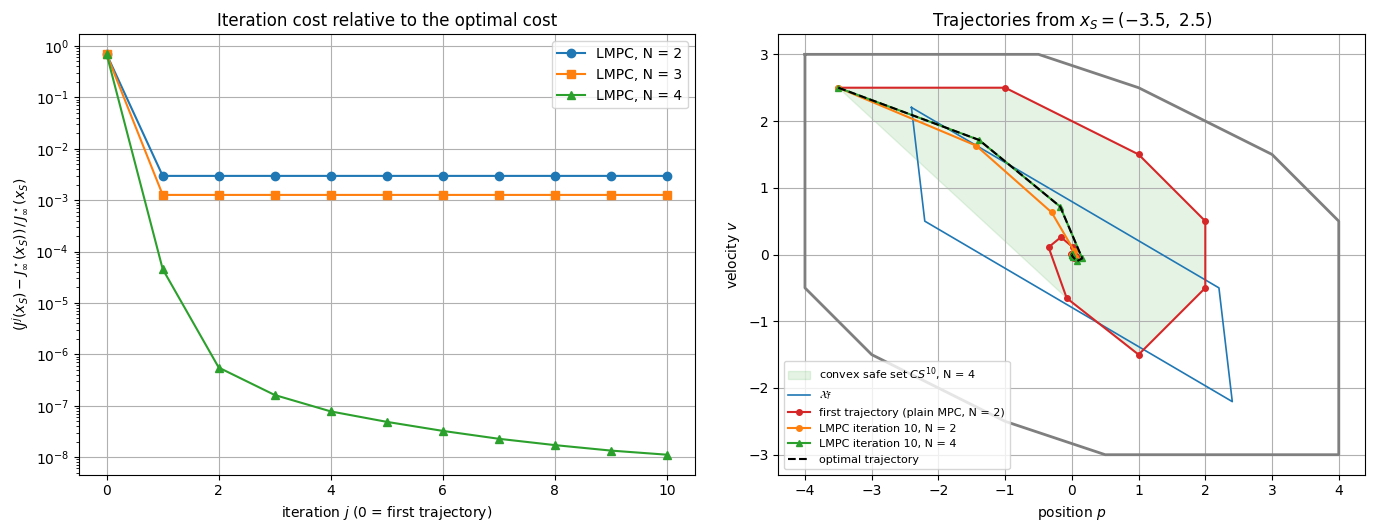

In [10]:
# Is the N = 2 plateau a solver artefact? Minimize the N = 2 LMPC objective at x_S by brute force:
# a grid search over (u0, u1), refined three times, with V_c evaluated by its LP at every point.
lmpc2 = lmpc_runs[2]["lmpc"]
S2, V2_values, _, _ = lmpc2.safe_data()


def lmpc_objective(u):
    x1 = A @ x_S + B[:, 0] * u[0]
    x2 = A @ x1 + B[:, 0] * u[1]
    if np.any(np.abs(u) > umax) or not (X.contains(x1) and X.contains(x2)):
        return np.inf
    value, _, ok = convex_safe_value(x2, S2, V2_values)
    return q(x_S, u[0]) + q(x1, u[1]) + value if ok else np.inf


sol2 = lmpc2.solve(x_S)
best_u, best = sol2.U.ravel(), lmpc_objective(sol2.U.ravel())
for h in [0.1, 0.01, 0.001]:
    center = best_u.copy()
    for a in np.linspace(-1, 1, 15):
        for b in np.linspace(-1, 1, 15):
            u = center + h * np.array([a, b])
            value = lmpc_objective(u)
            if value < best:
                best_u, best = u, value
print(f"N = 2 at x_S:  LMPC (SLSQP) objective = {sol2.objective:.9f},  brute-force minimum = {best:.9f}")
print(f"J^10 for N = 2: {lmpc_runs[2]['costs'][-1]:.9f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
ax = axes[0]
markers = {2: "o", 3: "s", 4: "^"}
for N, run in lmpc_runs.items():
    ax.semilogy(np.arange(len(run["costs"])), (run["costs"] - J_star) / J_star, marker=markers[N],
                label=f"LMPC, N = {N}")
ax.set_xlabel("iteration $j$ (0 = first trajectory)")
ax.set_ylabel(r"$(J^j(x_S)-J_\infty^\star(x_S))\,/\,J_\infty^\star(x_S)$")
ax.set_title("Iteration cost relative to the optimal cost")
ax.legend()

ax = axes[1]
stored = np.vstack(lmpc_runs[4]["trajectories"])
hull = HPolytope.from_vertices_2d(stored)
V_hull = hull.vertices_2d()
ax.fill(V_hull[:, 0], V_hull[:, 1], color="tab:green", alpha=0.12, label="convex safe set $CS^{10}$, N = 4")
plot_polytope(ax, C_inf, color="tab:gray", linewidth=2)
plot_polytope(ax, X_f, color="tab:blue", linewidth=1.2, label=r"$\mathcal{X}_f$")
ax.plot(X_seed[:, 0], X_seed[:, 1], "o-", color="tab:red", markersize=4, label="first trajectory (plain MPC, N = 2)")
for N, color in [(2, "tab:orange"), (4, "tab:green")]:
    Xl = lmpc_runs[N]["trajectories"][-1]
    ax.plot(Xl[:, 0], Xl[:, 1], markers[N] + "-", color=color, markersize=4, label=f"LMPC iteration 10, N = {N}")
ax.plot(r_opt["x"][:12, 0], r_opt["x"][:12, 1], "k--", linewidth=1.5, label="optimal trajectory")
ax.set_xlabel("position $p$")
ax.set_ylabel("velocity $v$")
ax.set_title(r"Trajectories from $x_S=(-3.5,\ 2.5)$")
ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

**Reading the output.** The first trajectory costs $28.087$, that is $1.69\,J_\infty^\star(x_S)$ with
$J_\infty^\star(x_S)=16.636$. For every horizon, one iteration removes almost all of the excess, and
no cost increases afterwards, as guaranteed: the largest increase is $9.9\times10^{-9}$, at solver
tolerance. Then the horizons part ways. With $N=4$ the gap keeps falling, to $1.1\times10^{-8}$, and
the trajectory joins the optimal one. With $N=3$ and $N=2$ it stalls after the first iteration, at
$1.27\times10^{-3}$ and $2.97\times10^{-3}$. The brute-force search confirms that the plateau is not
a solver artefact: with the data of iteration 10, the best $N=2$ plan at $x_S$ costs exactly
$J^{10}=16.685579$, the cost of the stored trajectory.

The guarantees say nothing about the limit, and notebook 05 (Part XX) already warned that
feasibility alone gives no optimality guarantee. The mechanism is the terminal cost. To improve, a
plan must leave the stored trajectory and end elsewhere in $CS^j$, where $V_c^j$ interpolates the
costs of suboptimal trajectories and over-estimates the optimal cost-to-go (Exercise B.6). A gain
that appears only later in the tail is invisible to a short plan, while a longer horizon optimizes
more of the tail explicitly. Even so, the $N=2$ limit is only $0.30\%$ above the optimum, against
$69\%$ for the trajectory that produced the first data.

<a id="part-b"></a>
# Part B — Derivations to reproduce

Each exercise is a derivation that Part A relied on. Work it out before opening the answer.

## B.1 The condensed QP

**Exercise.** Eliminate the states from the MPC problem of A.1 and write it as
$\min_U\ \tfrac12U^\top HU+f^\top U+c$ subject to $GU\le w$. Show that $H\succ0$ and say which
quantities depend on the current state $x_0$.

<details><summary>Answer</summary>

Stack $\mathbf x=(x_1,\ldots,x_N)$ and $U=(u_0,\ldots,u_{N-1})$. The dynamics give
$\mathbf x=S_xx_0+S_uU$ (`prediction_matrices`), with

$$
S_x=\begin{bmatrix}A\\A^2\\\vdots\\A^N\end{bmatrix},
\qquad
S_u=\begin{bmatrix}B&0&\cdots&0\\AB&B&\cdots&0\\\vdots&&\ddots&\vdots\\A^{N-1}B&A^{N-2}B&\cdots&B\end{bmatrix}.
$$

With $\bar Q=\operatorname{blkdiag}(Q,\ldots,Q,P)$ and $\bar R=\operatorname{blkdiag}(R,\ldots,R)$,
the cost is $x_0^\top Qx_0+\mathbf x^\top\bar Q\mathbf x+U^\top\bar RU$, and substitution gives

$$
H=2\,(S_u^\top\bar QS_u+\bar R),
\qquad
f=2\,S_u^\top\bar QS_xx_0,
\qquad
c=x_0^\top Qx_0+x_0^\top S_x^\top\bar QS_xx_0 .
$$

With $S_u^{(N)}$ the last block row of $S_u$ and $\mathcal X_f=\{x:\ H_fx\le h_f\}$, the constraints
are

$$
\begin{bmatrix}S_u\\-S_u\\I\\-I\\H_fS_u^{(N)}\end{bmatrix}U
\le
\begin{bmatrix}\mathbf 1\otimes x_{\max}-S_xx_0\\S_xx_0-\mathbf 1\otimes x_{\min}\\\mathbf 1\otimes u_{\max}\\-\mathbf 1\otimes u_{\min}\\h_f-H_fA^Nx_0\end{bmatrix}.
$$

$H\succ0$ because $\bar R\succ0$ and $S_u^\top\bar QS_u\succeq0$, so a feasible QP has a unique
minimizer. $H$ and $G$ are fixed, $f$ and $w$ are affine in $x_0$, and $c$ is quadratic: the MPC
problem is a multiparametric QP in $x_0$, which is why the MPC law is piecewise affine (explicit
MPC). `LinearMPC.solve` omits $c$, so its `objective` is not $J_N^\star$; `qp_data` of A.3 adds it
back.

</details>

The cell checks the formulas against direct rollouts at $x_S$ with $N=5$.

In [11]:
ctrl5 = make_mpc(5)
H, f, c, G, w = qp_data(ctrl5, x_S)
rng = np.random.default_rng(1)
cost_error, agree = 0.0, 0
for _ in range(1000):
    U = rng.uniform(umin, umax, size=5)
    xs = [x_S]
    for u in U:
        xs.append(A @ xs[-1] + B[:, 0] * u)
    direct = sum(q(x, u) for x, u in zip(xs[:-1], U)) + xs[-1] @ P @ xs[-1]
    cost_error = max(cost_error, abs(0.5 * U @ H @ U + f @ U + c - direct))
    admissible = all(X.contains(x, 1e-12) for x in xs[1:]) and X_f.contains(xs[-1], 1e-12)
    agree += admissible == bool(np.all(G @ U <= w + 1e-12))
sol = ctrl5.solve(x_S)
print(f"G has {G.shape[0]} rows;  smallest eigenvalue of H = {np.linalg.eigvalsh(H).min():.3f}")
print(f"1000 random U: max |condensed cost - rollout cost| = {cost_error:.1e}, "
      f"constraint test agrees with the rollout in {agree} cases")
print(f"LinearMPC objective + c = {sol.objective + c:.6f},  J_5^*(x_S) = {plan_cost(ctrl5, x_S, sol.U.ravel()):.6f}")

G has 34 rows;  smallest eigenvalue of H = 0.526
1000 random U: max |condensed cost - rollout cost| = 4.5e-13, constraint test agrees with the rollout in 1000 cases
LinearMPC objective + c = 16.636215,  J_5^*(x_S) = 16.636215


## B.2 KKT conditions of the CFTOC

**Exercise.** Write the KKT conditions (a) of the condensed QP and (b) of the problem with the states
kept as variables and multipliers $\lambda_{k+1}$ for the dynamics. Show that without inequality
constraints (b) reduces to the Riccati recursion, and interpret the inequality multipliers.

<details><summary>Answer</summary>

(a) $U^\star$ is optimal if and only if there is $\mu$ with

$$
HU^\star+f+G^\top\mu=0,
\qquad
GU^\star\le w,
\qquad
\mu\ge0,
\qquad
\mu_i\,(w-GU^\star)_i=0\ \ \text{for all } i .
$$

With affine constraints these conditions are necessary and sufficient. $U^\star$ is unique because
$H\succ0$; $\mu$ need not be, for instance when the active constraints are linearly dependent.

(b) With $G_xx_k\le g_x$, $G_uu_k\le g_u$ and $\mathcal X_f=\{H_fx\le h_f\}$, stationarity of the
Lagrangian reads

$$
\begin{aligned}
u_k:&\quad 2Ru_k+B^\top\lambda_{k+1}+G_u^\top\nu_k=0, && k=0,\ldots,N-1,\\
x_k:&\quad \lambda_k=2Qx_k+A^\top\lambda_{k+1}+G_x^\top\mu_k, && k=1,\ldots,N-1,\\
x_N:&\quad \lambda_N=2Px_N+G_x^\top\mu_N+H_f^\top\eta,
\end{aligned}
$$

plus primal feasibility, $\mu_k,\nu_k,\eta\ge0$ and complementary slackness: the costates run
backwards, as in the discrete-time maximum principle. Without inequalities, try
$\lambda_k=2P_kx_k$. The $u_k$-condition gives $u_k=-(R+B^\top P_{k+1}B)^{-1}B^\top P_{k+1}Ax_k$,
and the $x_k$-condition then gives
$P_k=Q+A^\top P_{k+1}A-A^\top P_{k+1}B(R+B^\top P_{k+1}B)^{-1}B^\top P_{k+1}A$ with $P_N=P$: the
Riccati recursion. With $P$ from the DARE, $P_k=P$ for all $k$, which is why the MPC equals the LQR
inside $\mathcal X_f$.

A multiplier is the price of its constraint: if the active set does not change,
$\partial J_N^\star/\partial w_i=-\mu_i$, so relaxing constraint $i$ by $\varepsilon$ lowers the
optimal cost by about $\mu_i\varepsilon$. C.4 uses this to size slack penalties.

</details>

The cell recovers $\mu$ at $x_S$ ($N=5$) from the active constraints and checks the price
interpretation by re-solving with one bound relaxed.

In [12]:
names = ([f"{s}_{k} <= max" for k in range(1, 6) for s in ("p", "v")]
         + [f"{s}_{k} >= min" for k in range(1, 6) for s in ("p", "v")]
         + [f"u_{k} <= 1" for k in range(5)] + [f"u_{k} >= -1" for k in range(5)]
         + [f"terminal row {j}" for j in range(len(X_f.h))])
U_opt = exact_qp(H, f, G, w)                          # exact solution (A.3), so KKT holds to round-off
J_opt = 0.5 * U_opt @ H @ U_opt + f @ U_opt + c
gradient = H @ U_opt + f
active = np.flatnonzero(w - G @ U_opt <= 1e-9)
mu_active, _ = nnls(G[active].T, -gradient)           # mu >= 0 with G_A' mu = -(H U + f)
print("optimal plan U* =", U_opt)
print("active constraints:", [names[i] for i in active], "  multipliers:", mu_active)
print(f"stationarity residual |HU + f + G_A' mu| = {np.linalg.norm(gradient + G[active].T @ mu_active):.1e}")

i, mu_i = active[np.argmax(mu_active)], mu_active.max()
eps = 1e-4
w_relaxed = w.copy()
w_relaxed[i] += eps
U_relaxed = exact_qp(H, f, G, w_relaxed)
dJ = (0.5 * U_relaxed @ H @ U_relaxed + f @ U_relaxed + c) - J_opt
print(f"relax '{names[i]}' by {eps:g}: optimal cost changes by {dJ:.4e};  -mu_i * eps = {-mu_i * eps:.4e}")

optimal plan U* = [-0.7828 -1.     -0.775  -0.042   0.0693]
active constraints: ['u_1 >= -1']   multipliers: [0.4944]
stationarity residual |HU + f + G_A' mu| = 8.0e-14
relax 'u_1 >= -1' by 0.0001: optimal cost changes by -4.9436e-05;  -mu_i * eps = -4.9441e-05


## B.3 Recursive feasibility by the shifted sequence

**Exercise.** Let $x\in\mathcal X_N$ with optimal plan $(u_0^\star,\ldots,u_{N-1}^\star)$ and predicted
states $x_1^\star,\ldots,x_N^\star$. Show that $x^+=Ax+Bu_0^\star\in\mathcal X_N$. Which conditions of
A.1 are used? Is optimality needed?

<details><summary>Answer</summary>

From $x^+=x_1^\star$ take the shifted plan $(u_1^\star,\ldots,u_{N-1}^\star,\,-Kx_N^\star)$. Its states
$x_2^\star,\ldots,x_N^\star$ lie in $\mathcal X$; since $x_N^\star\in\mathcal X_f$, condition 1 gives
$-Kx_N^\star\in\mathcal U$ and condition 2 gives $A_Kx_N^\star\in\mathcal X_f\subseteq\mathcal X$.
So $x^+\in\mathcal X_N$. Neither condition 3 nor optimality is used: any feasible plan has a feasible
successor, which makes the shifted plan a valid warm start and fallback (C.3, C.6). The argument does
need a plant equal to the model (C.1, C.2).

</details>

## B.4 Lyapunov decrease and the upper bound

**Exercise.** Using the plan of B.3, prove $J_N^\star(x^+)\le J_N^\star(x)-q(x,u_0^\star)$. Then prove
$J_N^\star\le V_f$ on $\mathcal X_f$, and explain what this bound adds to the argument of notebook 03.

<details><summary>Answer</summary>

The shifted plan costs

$$
\tilde J=J_N^\star(x)-q(x,u_0^\star)+\Big[q(x_N^\star,-Kx_N^\star)+V_f(A_Kx_N^\star)-V_f(x_N^\star)\Big],
$$

where the bracket is $\le0$ by condition 3, and $J_N^\star(x^+)\le\tilde J$ by optimality. For
$x\in\mathcal X_f$ the plan $u_k=-Kx_k$ is feasible by conditions 1–2, and summing condition 3 along
it gives $\sum_{k=0}^{N-1}q(x_k,-Kx_k)+V_f(x_N)\le V_f(x)$, hence
$J_N^\star(x)\le V_f(x)\le\lambda_{\max}(P)\|x\|^2$.

The lower bound $J_N^\star(x)\ge\lambda_{\min}(Q)\|x\|^2$ and the decrease give
$\sum_t\|x(t)\|^2<\infty$, hence convergence. Only the upper bound makes small initial states stay
small:
$\lambda_{\min}(Q)\|x(t)\|^2\le J_N^\star(x(t))\le J_N^\star(x(0))\le\lambda_{\max}(P)\|x(0)\|^2$ for
$x(0)\in\mathcal X_f$. With both bounds quadratic,
$J_N^\star(x^+)\le\big(1-\lambda_{\min}(Q)/c_2\big)J_N^\star(x)$, with $c_2=\lambda_{\max}(P)=1.911$
on $\mathcal X_f$ and a larger constant on the bounded $\mathcal X_N$: exponential stability.

</details>

## B.5 Invariance of the convex safe set

**Exercise.** Each stored state $s_i$ has a stored input $u_i\in\mathcal U$ and a stored successor
$s_i^+=As_i+Bu_i$, and the target is stored as an equilibrium with $u=0$. Show that
$CS=\operatorname{conv}\{s_i\}$ is control invariant when $\mathcal X$ and $\mathcal U$ are convex.
Which step fails for a nonlinear model, and which for a non-convex $\mathcal X$?

<details><summary>Answer</summary>

Write $x=\sum_i\lambda_is_i$ with $\lambda\ge0$, $\mathbf 1^\top\lambda=1$, and apply
$u=\sum_i\lambda_iu_i\in\mathcal U$. By linearity,
$Ax+Bu=\sum_i\lambda_i(As_i+Bu_i)=\sum_i\lambda_is_i^+\in CS$, because every successor is a stored
state; and $CS\subseteq\mathcal X$ by convexity. For a nonlinear model the linearity step fails, so
only the sampled set $\{s_i\}$ stays invariant, which leads to mixed-integer problems or local
convexifications (Part D). For a non-convex $\mathcal X$, such as the obstacle avoidance of notebook
04, a convex combination of admissible states can be inadmissible.

</details>

## B.6 The barycentric terminal cost

**Exercise.** With the stored states as the rows of $S$ and realized costs-to-go
$J_i=q(s_i,u_i)+J_i^+$ in $\mathbf J$, let
$V_c(x)=\min_\lambda\{\mathbf J^\top\lambda:\ S^\top\lambda=x,\ \mathbf 1^\top\lambda=1,\ \lambda\ge0\}$.
Show that (a) $V_c$ is convex on $CS$ with $V_c(s_i)\le J_i$; (b) if $\lambda$ is optimal at $x$ and
$u=\sum_i\lambda_iu_i$, then $V_c(Ax+Bu)\le V_c(x)-q(x,u)$; (c) $V_c\ge J_\infty^\star$ on $CS$.

<details><summary>Answer</summary>

(a) If $\lambda$ and $\lambda'$ are optimal at $x$ and $x'$, then $\theta\lambda+(1-\theta)\lambda'$ is
feasible at $\theta x+(1-\theta)x'$ with cost $\theta V_c(x)+(1-\theta)V_c(x')$, so $V_c$ is convex
(and piecewise affine, as the value of an LP with right-hand side affine in $x$). Choosing
$\lambda=e_i$ gives $V_c(s_i)\le J_i$. Geometrically, $V_c$ is the lower convex envelope of the points
$(s_i,J_i)$.

(b) By linearity $Ax+Bu=\sum_i\lambda_is_i^+$, so the same weights on the successors are feasible at
$x^+$, and convexity of $q$ gives $q(x,u)\le\sum_i\lambda_iq(s_i,u_i)$. Hence

$$
V_c(x^+)\le\sum_i\lambda_iJ_i^+=\sum_i\lambda_iJ_i-\sum_i\lambda_iq(s_i,u_i)\le V_c(x)-q(x,u).
$$

With B.5, these are conditions 1–3 of A.1 for $\mathcal X_f=CS$, $V_f=V_c$ and the local controller
$u=\sum_i\lambda_iu_i$, so B.3 and B.4 apply to LMPC unchanged.

(c) Each $J_i$ is the cost of an admissible trajectory, so $J_i\ge J_\infty^\star(s_i)$, and
$J_\infty^\star$ is convex (linear dynamics, convex constraints and cost). For $\lambda$ optimal at
$x$: $V_c(x)=\sum_i\lambda_iJ_i\ge\sum_i\lambda_iJ_\infty^\star(s_i)\ge J_\infty^\star(x)$. The
learned terminal cost is pessimistic, which is the mechanism behind the plateau of A.5.

</details>

The cell checks (b) and (c) on 200 random convex combinations of three stored states, with the data
of the $N=2$ and $N=4$ runs of A.5.

In [13]:
def J_inf_exact(x):
    # J_inf^*(x) = J_12^*(x) of the terminal design (A.4), solved with the exact QP solver of A.3.
    H_, f_, c_, G_, w_ = qp_data(ref_upper, x)
    U_ = exact_qp(H_, f_, G_, w_ + RELAX)
    return 0.5 * U_ @ H_ @ U_ + f_ @ U_ + c_


for N in [2, 4]:
    S, J_stored, U_stored, _ = lmpc_runs[N]["lmpc"].safe_data()
    rng = np.random.default_rng(2)
    residual, excess, relative = [], [], []
    for _ in range(200):
        idx = rng.choice(len(S), size=3, replace=False)
        x = rng.dirichlet(np.ones(3)) @ S[idx]
        Vc, lam, ok = convex_safe_value(x, S, J_stored)
        u = lam @ U_stored
        Vc_next, _, ok_next = convex_safe_value(A @ x + B @ u, S, J_stored)
        residual.append(Vc_next - Vc + q(x, u))
        J_x = J_inf_exact(x)
        excess.append(Vc - J_x)
        if J_x >= 0.1:
            relative.append((Vc - J_x) / J_x)
    print(f"LMPC data, N = {N} ({len(S)} stored states): max decrease residual = {max(residual):.1e}, "
          f"min (V_c - J_inf^*) = {min(excess):.1e}, median (V_c - J_inf^*)/J_inf^* = {np.median(relative):.1%} "
          f"(over the {len(relative)} points with J_inf^* >= 0.1)")

LMPC data, N = 2 (101 stored states): max decrease residual = -3.4e-13, min (V_c - J_inf^*) = 3.7e-10, median (V_c - J_inf^*)/J_inf^* = 56.6% (over the 99 points with J_inf^* >= 0.1)


LMPC data, N = 4 (131 stored states): max decrease residual = -8.3e-11, min (V_c - J_inf^*) = 1.3e-09, median (V_c - J_inf^*)/J_inf^* = 77.1% (over the 92 points with J_inf^* >= 0.1)


**Reading the output.** Inequality (b) holds to round-off, and $V_c\ge J_\infty^\star$ everywhere.
Between stored states, $V_c$ over-estimates $J_\infty^\star$ by a median of $57\%$ ($N=2$ data) and
$77\%$ ($N=4$ data) at these random points. LMPC with $N=4$ still reaches the optimum because $V_c$
only needs to be accurate near the optimal trajectory, where the stored states accumulate.

<a id="part-c"></a>
# Part C — Engineering judgment

Parts A and B assumed an exact model, an exact solver and a measured state. What if they fail?

## C.1 Model mismatch

The plant is $x^+=(A+\Delta A)x+(B+\Delta B)u$, but the MPC uses $(A,B)$. Which guarantees survive?

<details><summary>Answer</summary>

Strictly, none: every proof used $x^+=x_1^\star$. With a continuous value function, linear MPC has
some inherent robustness, so for small mismatch the state still reaches a neighbourhood of the
origin. Near active constraints, however, a small error can push the state out of $\mathcal X_N$,
into the doomed states of A.4. Remedies: a better model, constraint margins, offset-free MPC (an
integrating disturbance model with an observer), or a robust design (C.2).

</details>

## C.2 Disturbances, robust and tube MPC

With $x^+=Ax+Bu+w$ and $w\in\mathcal W$ bounded, how can constraint satisfaction and recursive
feasibility be guaranteed?

<details><summary>Answer</summary>

Tube MPC (Mayne, Seron and Raković, 2005) plans for the nominal model $z^+=Az+Bv$ and applies
$u=v+K(x-z)$. The error $e=x-z$ obeys $e^+=A_Ke+w$ and stays in a robust positively invariant set
$\mathcal E$, with $A_K\mathcal E\oplus\mathcal W\subseteq\mathcal E$. Planning with the tightened
sets $\mathcal X\ominus\mathcal E$ and $\mathcal U\ominus K\mathcal E$ makes B.3 apply to $z$, and
$x\in z\oplus\mathcal E\subseteq\mathcal X$ for every disturbance sequence. The price is a smaller
feasible set and convergence to $\mathcal E$ instead of the origin.

</details>

## C.3 Real-time solvers

The QP must be solved within one sampling period. What are the options, and what if the solver does
not finish?

<details><summary>Answer</summary>

Small dense QPs suit warm-started active-set solvers (qpOASES); long horizons favour sparse
interior-point (HPIPM) or first-order (OSQP) methods; tiny problems can use the explicit
piecewise-affine law of B.1. If the solver stops early, the shifted plan of B.3 is feasible, and any
feasible plan that costs no more preserves the decrease of B.4 ("feasibility implies stability",
Scokaert, Mayne and Rawlings, 1999). As A.3 showed, a failure flag must be checked, not trusted.

</details>

## C.4 Soft constraints and slack penalties

How should constraints be softened so that the QP is always feasible, and how large must the penalty
be?

<details><summary>Answer</summary>

Use $G_xx_k\le g_x+\varepsilon_k$ with $\varepsilon_k\ge0$ and add
$\rho\,\mathbf 1^\top\varepsilon+\varepsilon^\top S\varepsilon$ to the cost, for state constraints
only (input bounds are physical limits). If $\rho$ exceeds the largest multiplier of the hard problem
(B.2), the penalty is exact: the soft QP returns the hard solution whenever the hard problem is
feasible (Kerrigan and Maciejowski, 2000). A purely quadratic penalty is never exact. Softening
restores feasibility of the QP, not the guarantees.

</details>

## C.5 Estimation and delays

Only $y=Cx+v$ is measured, and the input acts after $d$ steps. What changes?

<details><summary>Answer</summary>

An observer (a Kalman filter, or moving-horizon estimation, which handles constraints) provides
$\hat x$. Using $\hat x$ as if it were $x$ is standard, but the separation principle does not extend
to constrained MPC: the estimation error acts as a disturbance, which output-feedback tube MPC covers
by tightening the constraints. A known delay is handled by prediction: solve from $x(t+d)$, predicted
with the inputs already sent. Computation time is a one-step delay of the same kind.

</details>

## C.6 Safety fallbacks

What should the controller do when the QP is infeasible or the solver fails?

<details><summary>Answer</summary>

Use layers: the rest of the previous plan, feasible for $N-1$ steps in the nominal case (B.3) and
followed by $-Kx$ inside $\mathcal X_f$; then a softened QP that minimizes the violation (C.4); last,
a backup controller with its own invariant set, such as maximal braking, certified offline. An
independent check like the LP of A.3 tells "no admissible plan exists" apart from "the solver
failed". In LMPC, the stored continuation $u=\sum_i\lambda_iu_i$ of B.5 keeps the state in $CS^j$.

</details>

<a id="part-d"></a>
# Part D — Where to go next

## D.1 Robust and stochastic MPC

Tube MPC (C.2), constraint tightening and min-max formulations for bounded disturbances; chance
constraints and stochastic tubes for random ones. See Rawlings, Mayne and Diehl (2022, chapter 3) and
Kouvaritakis and Cannon (2016).

## D.2 Nonlinear and economic MPC

For nonlinear models, terminal ingredients come from the linearization at the equilibrium
(quasi-infinite-horizon MPC, Chen and Allgöwer, 1998). Without terminal ingredients, stability can be
proved for long enough horizons under controllability assumptions (Grüne and Pannek, 2017): this is
the route to turning the observations of A.4 into guarantees. Economic MPC drops positive-definite stage costs and replaces
the Lyapunov argument by dissipativity.

## D.3 Learning MPC beyond linear systems

The convex safe set is not invariant for nonlinear dynamics (B.5). The alternatives are a sampled
safe set with a mixed-integer terminal constraint, or local convex safe sets with local models
identified from data, as in the racing applications of notebooks 06 and 07 (Rosolia and Borrelli,
2020).

## D.4 Data-driven models

Identification with error bounds feeds robust MPC, Gaussian-process models provide uncertainty
estimates, and methods based on Willems' fundamental lemma replace the model by a Hankel matrix of
measured data (Coulson, Lygeros and Dörfler, 2019).

## D.5 Embedded solvers

OSQP (operator splitting), qpOASES (parametric active set), HPIPM and acados (structure-exploiting
interior point and code generation), and explicit MPC by multiparametric programming (Bemporad et
al., 2002).

## D.6 Projects on this repository

1. Replace SLSQP in the QP wrapper by an active-set or ADMM solver and rerun the audit of A.3.
2. Add a disturbance $|w_i|\le0.05$, implement tube MPC, and repeat the grid check of A.3.
3. Soften the state constraints with an exact penalty (C.4) and test it under model mismatch.
4. Repeat A.5 from other first trajectories: does the $N=2$ plateau move?

<a id="part-e"></a>
# Part E — Summary and references

**Summary.**

- **LQR terminal ingredients:** $V_f$ decreases with equality, $\mathcal X_f$ is limited by the
  input bound, and the feasible sets $\mathcal X_N$ are nested, control invariant and equal to
  $\mathcal C_\infty$ from $N=5$.
- **Grid certificate:** over $17\,640$ closed-loop QPs, no loss of feasibility, a decrease residual
  of at most $5.3\times10^{-8}$, and $J_N^\star=V_f$ on $\mathcal X_f$. The single SLSQP failure was
  a degenerate but feasible QP, certified by an LP.
- **No terminal ingredients:** $N=1$ lost feasibility from 100 states of $\mathcal C_\infty$, and
  $N=2$ accepted doomed states and cost up to $2.15\,J_\infty^\star$. From $N=3$ on the grid
  behaved, but without a certificate.
- **Learning MPC:** from $1.69\,J_\infty^\star$ the costs never increased. $N=4$ reached
  $J_\infty^\star$, while $N=2$ and $N=3$ stalled $0.30\%$ and $0.13\%$ above it, because $V_c$ is
  pessimistic between data.

**References.**

- F. Borrelli, A. Bemporad and M. Morari, *Predictive Control for Linear and Hybrid Systems*,
  Cambridge University Press, 2017.
- J. B. Rawlings, D. Q. Mayne and M. M. Diehl, *Model Predictive Control: Theory, Computation, and
  Design*, 2nd ed., Nob Hill Publishing, 2022.
- D. Q. Mayne, J. B. Rawlings, C. V. Rao and P. O. M. Scokaert, "Constrained model predictive
  control: Stability and optimality", *Automatica*, 36(6), 789–814, 2000.
- U. Rosolia and F. Borrelli, "Learning Model Predictive Control for Iterative Tasks. A Data-Driven
  Control Framework", *IEEE Transactions on Automatic Control*, 63(7), 1883–1896, 2018.
- U. Rosolia and F. Borrelli, "Learning how to autonomously race a car: a predictive control
  approach", *IEEE Transactions on Control Systems Technology*, 28(6), 2713–2719, 2020.
- E. G. Gilbert and K. T. Tan, "Linear systems with state and control constraints: The theory and
  application of maximal output admissible sets", *IEEE Transactions on Automatic Control*, 36(9),
  1008–1020, 1991.
- P. O. M. Scokaert, D. Q. Mayne and J. B. Rawlings, "Suboptimal model predictive control
  (feasibility implies stability)", *IEEE Transactions on Automatic Control*, 44(3), 648–654, 1999.
- D. Q. Mayne, M. M. Seron and S. V. Raković, "Robust model predictive control of constrained linear
  systems with bounded disturbances", *Automatica*, 41(2), 219–224, 2005.
- E. C. Kerrigan and J. M. Maciejowski, "Soft constraints and exact penalty functions in model
  predictive control", *Proceedings of the UKACC International Conference on Control*, 2000.
- C. L. Lawson and R. J. Hanson, *Solving Least Squares Problems*, Prentice-Hall, 1974.
- H. Chen and F. Allgöwer, "A quasi-infinite horizon nonlinear model predictive control scheme with
  guaranteed stability", *Automatica*, 34(10), 1205–1217, 1998.
- L. Grüne and J. Pannek, *Nonlinear Model Predictive Control: Theory and Algorithms*, 2nd ed.,
  Springer, 2017.
- B. Kouvaritakis and M. Cannon, *Model Predictive Control: Classical, Robust and Stochastic*,
  Springer, 2016.
- A. Bemporad, M. Morari, V. Dua and E. N. Pistikopoulos, "The explicit linear quadratic regulator
  for constrained systems", *Automatica*, 38(1), 3–20, 2002.
- J. Coulson, J. Lygeros and F. Dörfler, "Data-enabled predictive control: In the shallows of the
  DeePC", *Proceedings of the European Control Conference*, 2019.